In [10]:
import numpy as np
from nn.nn import NeuralNetwork
import sklearn.datasets
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Step 2: Making an autoencoder for the digits dataset

In [7]:
# Load dataset
digits = sklearn.datasets.load_digits()

X = digits.data
y = digits.target

# Split (e.g., 80% train, 20% validation)
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # keeps class balance
)

print(X_train.shape, X_val.shape)
print(y_train.shape, y_val.shape)

(1437, 64) (360, 64)
(1437,) (360,)


In [16]:
nn_arch = [
    {'input_dim': 64, 'output_dim': 16, 'activation': 'relu'},
    {'input_dim': 16, 'output_dim': 64, 'activation': 'relu'},
]

model = NeuralNetwork(
    nn_arch,
    lr=0.001,        
    seed=42,         
    batch_size=8,   
    epochs=200,
    loss_function='mean_squared_error',
)

In [17]:
# For an autoencoder the target is the input (X reconstructs X)
train_losses, val_losses = model.fit(X_train, X_train, X_val, X_val)
print(f"Final train loss: {train_losses[-1]:.4f} | Final val loss: {val_losses[-1]:.4f}")

Final train loss: 45.7960 | Final val loss: 2141.1968


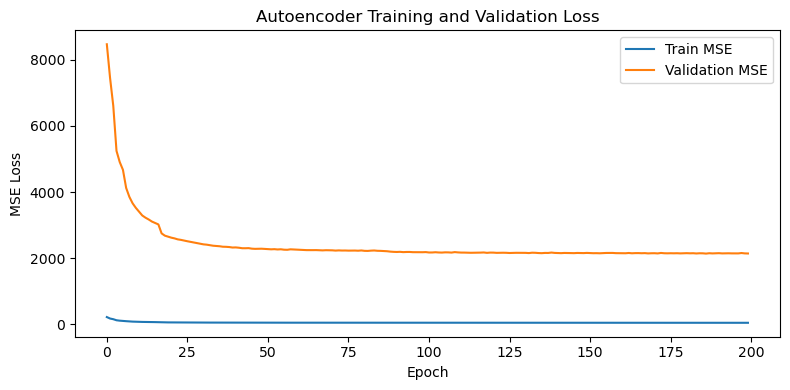

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train MSE')
plt.plot(val_losses,   label='Validation MSE')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Average reconstruction error over the validation set
X_val_reconstructed = model.predict(X_val)

# Per-sample MSE: mean over 64 features, then mean over all validation samples
per_sample_mse = np.mean((X_val - X_val_reconstructed) ** 2, axis=1)
avg_reconstruction_error = np.mean(per_sample_mse)

print(f"Average per-sample reconstruction MSE (validation set): {avg_reconstruction_error:.4f}")
print(f"  (pixel values are in [0, 16], so an MSE of {avg_reconstruction_error:.2f} corresponds to "
      f"~{avg_reconstruction_error**0.5:.2f} pixel RMSE per feature)")

Average per-sample reconstruction MSE (validation set): 6.0017
  (pixel values are in [0, 16], so an MSE of 6.00 corresponds to ~2.45 pixel RMSE per feature)


I chose a learning rate of 0.001 because a larger rate caused unstable training. I tried a batch size of 8 and of 32. I chose 8 because I got smoother loss curves. 200 epochs is enough for the loss to plateau on this dataset. MSE is the natural loss for reconstruction since we are measuring pixel-level distance between input and output. ReLU is used for both layers because the pixel values are non-negative, so ReLU can reconstruct them directly without any rescaling, and it avoids the vanishing gradient problem that sigmoid would introduce.

## Step 3: Making a classifier for transcription factor binding

In [2]:
# import additional libraries
import pandas as pd
from nn.preprocess import sample_seqs, one_hot_encode_seqs
from nn.io import read_text_file, read_fasta_file

In [3]:
pos = read_text_file('data/rap1-lieb-positives.txt')
print('# Rap1+ samples: ' + str(len(pos)))
print('Min Rap1+ length: ' + str(np.min([len(seq) for seq in pos])))
print('Max Rap1+ length: ' + str(np.max([len(seq) for seq in pos])))
print('Avg Rap1+ length: ' + str(np.mean([len(seq) for seq in pos])) + '\n')

neg = read_fasta_file('data/yeast-upstream-1k-negative.fa')
print('# Rap1- samples: ' + str(len(neg)))
print('Min Rap1- length: ' + str(np.min([len(seq) for seq in neg])))
print('Max Rap1- length: ' + str(np.max([len(seq) for seq in neg])))
print('Avg Rap1- length: ' + str(np.mean([len(seq) for seq in neg])))

# Rap1+ samples: 137
Min Rap1+ length: 17
Max Rap1+ length: 17
Avg Rap1+ length: 17.0

# Rap1- samples: 3163
Min Rap1- length: 52
Max Rap1- length: 1000
Avg Rap1- length: 999.1454315523238


In [4]:
# need to clip negative samples to be the same length as the positive samples
neg = [seq[:len(pos[0])] for seq in neg]
print('Min Rap1- length: ' + str(np.min([len(seq) for seq in neg])))
print('Max Rap1- length: ' + str(np.max([len(seq) for seq in neg])))

Min Rap1- length: 17
Max Rap1- length: 17


### balance classes, one-hot encode, train/val split

In [5]:
# Combine positives and negatives, then balance with sample_seqs
all_seqs   = pos + neg
all_labels = [True] * len(pos) + [False] * len(neg)

np.random.seed(42)
X_seqs, y_labels = sample_seqs(all_seqs, all_labels)

print(f"Balanced dataset: {sum(y_labels)} positives, {sum(not l for l in y_labels)} negatives")

# One-hot encode: each 17-mer → vector of length 17*4 = 68
X_encoded = one_hot_encode_seqs(X_seqs)
y_arr = np.array(y_labels, dtype=float).reshape(-1, 1)

print(f"X shape: {X_encoded.shape}, y shape: {y_arr.shape}")

Balanced dataset: 3163 positives, 3163 negatives
X shape: (6326, 68), y shape: (6326, 1)


In [6]:
# Train/validation split (80/20, stratified)
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(
    X_encoded, y_arr,
    test_size=0.2,
    random_state=42,
    stratify=y_arr
)

print(f"Train: {X_train_r.shape}, Val: {X_val_r.shape}")

Train: (5060, 68), Val: (1266, 68)


In [7]:
# 68 → 32 → 1 classifier
# Input: one-hot encoded 17-mer (68 features)
# Hidden: 32 neurons with ReLU
# Output: 1 neuron with sigmoid (probability of being a Rap1 binding site)
rap1_arch = [
    {'input_dim': 68, 'output_dim': 32, 'activation': 'relu'},
    {'input_dim': 32, 'output_dim': 1,  'activation': 'sigmoid'},
]

rap1_model = NeuralNetwork(
    rap1_arch,
    lr=0.01,
    seed=42,
    batch_size=32,
    epochs=200,
    loss_function='binary_cross_entropy',
)

In [8]:
rap1_train_losses, rap1_val_losses = rap1_model.fit(X_train_r, y_train_r, X_val_r, y_val_r)
print(f"Final train loss: {rap1_train_losses[-1]:.4f} | Final val loss: {rap1_val_losses[-1]:.4f}")

Final train loss: 0.0455 | Final val loss: 14.5733


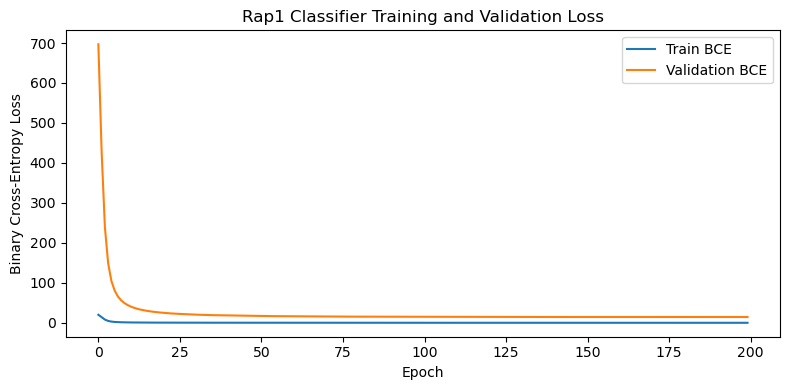

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(rap1_train_losses, label='Train BCE')
plt.plot(rap1_val_losses,   label='Validation BCE')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.title('Rap1 Classifier Training and Validation Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# Accuracy on validation set: threshold sigmoid output at 0.5
y_val_probs = rap1_model.predict(X_val_r)
y_val_preds = (y_val_probs >= 0.5).astype(float)

accuracy = np.mean(y_val_preds == y_val_r)
print(f"Validation accuracy: {accuracy * 100:.2f}%")

Validation accuracy: 99.61%


I used binary cross-entropy as the loss function because this is a binary classification task and binary cross-entropy directly measures how well the predicted probabilities match the true labels, which is more appropriate than MSE for classification.

For sampling, I oversampled the minority class (137 positives) with replacement to match the number of negatives (3163). This avoids the model simply learning to predict everything as negative, which would give high accuracy but no real discriminative power. Oversampling with replacement is simple and preserves all original positive examples while introducing augmented repeats.

I chose a learning rate of 0.01 because the one-hot inputs are already in [0,1] and this rate gives fast but stable convergence. A batch size of 32 here instead of 8 like before since this is a larger dataset. The architecture (68x32x1) gives the model enough capacity to learn motif patterns in the 17-mer without overfitting on a relatively small dataset. 200 epochs is sufficient for the loss to plateau.